In [2]:
%%html
<style>
/* Any CSS style can go in here. */
.dataframe th {
    font-size: 12px;
}
.dataframe td {
    font-size: 10px;
}
</style>

check_point: 543942, train_eval: train, max_10_loss: [[22.96089923 22.76132334 21.50524825 19.89207616 17.95483732 16.8393748
  14.4405479  12.93072279]
 [16.64237639 14.23049727 12.28205107 11.84764663 11.40895166  9.67703246
   9.11979866  8.5919229 ]
 [14.68674223 13.1434423  10.47859033  8.5928353   7.69414694  7.60827077
   7.28138877  7.09725244]
 [13.77704982 11.12891937  9.78222888  7.94175777  6.37227861  6.3092761
   5.58032425  4.85360729]
 [12.58771618  9.24878928  8.09564834  7.3765413   7.03451258  5.26644076
   5.02995684  4.51164585]
 [ 8.19025911  7.95756199  7.48877823  6.83177363  5.96280064  5.1212466
   4.39809731  4.00914883]
 [ 7.24710716  6.87548838  5.62238949  4.6024362   4.01987761  3.34847758
   3.23045463  2.76578002]]


,0,1,2,3,4,5,6,7
0,SIE4x4-h2o2+_1.75,SIE4x4-nh32+_1.75,BH9-08_9R2,W4_11-p4,SIE4x4-nh32+_1.5,SIE4x4-h2o2+_1.5,SIE4x4-h2+_1.75,W4_11-oclo
1,SIE4x4-h2o2+_1.75,BH9-08_9R2,W4_11-p4,SIE4x4-nh32+_1.75,SIE4x4-h2o2+_1.5,W4_11-s4-c2v,W4_11-o2,W4_11-alcl3
2,BH9-08_9R2,SIE4x4-h2o2+_1.75,SIE4x4-nh32+_1.75,SIE4x4-h2o2+_1.5,SIE4x4-nh32+_1.0,W4_11-o2,W4_11-cs2,W4_11-p4
3,BH9-08_9R2,SIE4x4-h2o2+_1.75,SIE4x4-nh32+_1.75,SIE4x4-nh32+_1.0,W4_11-ccl2,SIE4x4-h2o2+_1.5,W4_11-o2,SIE4x4-h2o2+_1.0
4,BH9-08_9R2,SIE4x4-h2o2+_1.75,SIE4x4-nh32+_1.75,SIE4x4-nh32+_1.0,W4_11-ccl2,SIE4x4-h2o2+_1.0,W4_11-cloo,W4_11-cn
5,SIE4x4-h2o2+_1.75,SIE4x4-nh32+_1.75,BH9-08_9R2,SIE4x4-nh32+_1.0,W4_11-ccl2,SIE4x4-h2o2+_1.0,W4_11-cloo,W4_11-cn
6,SIE4x4-nh32+_1.75,SIE4x4-h2o2+_1.75,SIE4x4-nh32+_1.0,SIE4x4-h2o2+_1.0,W4_11-cloo,W4_11-cn,W4_11-ccl2,W4_11-sif


check_point: 543942, train_eval: eval, max_10_loss: [[6.57898012e+00 5.55901094e+00 1.51472407e+00]
 [1.22297536e+01 7.09208189e+00 3.63617657e+00]
 [1.09507868e+01 9.91238033e+00 1.22875763e-02]
 [1.14652193e+01 8.11414256e+00 1.24420038e+00]
 [1.31322172e+01 7.57851577e+00 3.43002872e-01]
 [1.41780320e+01 7.22708626e+00 9.96047355e-01]
 [1.49113561e+01 7.00826205e+00 1.22589370e+00]]


,0,1,2
0,W4_11-cf4,ALK8-li4_c,W4_11-sif4
1,W4_11-cf4,ALK8-li4_c,W4_11-sif4
2,ALK8-li4_c,W4_11-cf4,W4_11-sif4
3,ALK8-li4_c,W4_11-cf4,W4_11-sif4
4,ALK8-li4_c,W4_11-cf4,W4_11-sif4
5,ALK8-li4_c,W4_11-cf4,W4_11-sif4
6,ALK8-li4_c,W4_11-cf4,W4_11-sif4


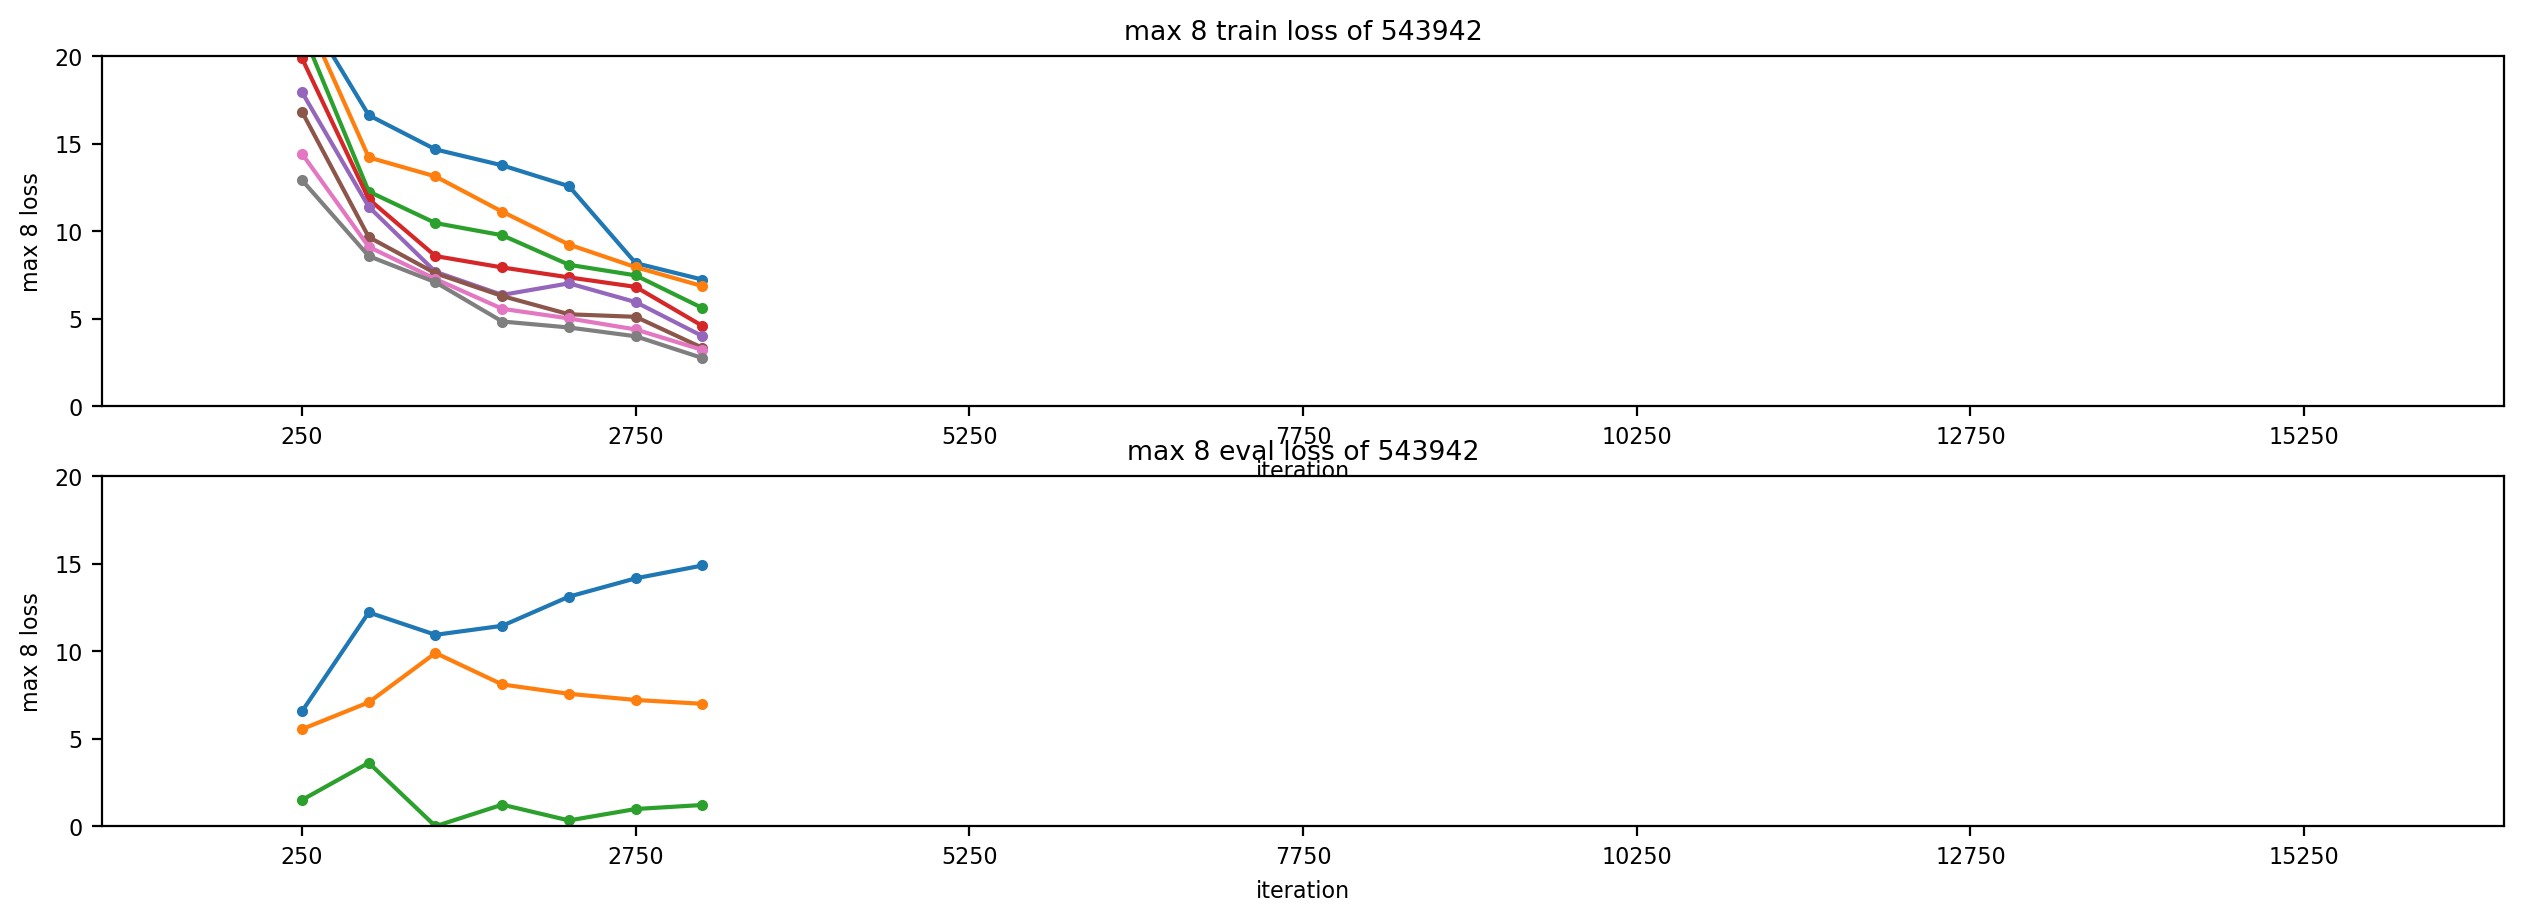

<Figure size 1550x500 with 0 Axes>

In [11]:
import pandas as pd
from pathlib import Path

import numpy as np

import matplotlib.pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format='retina'

plt.rcParams["figure.figsize"] = (15.5, 5)
plt.rcParams["font.size"] = 8

number_of_max = 8

check_point_list = [
    "543942",
]

f, axes = plt.subplots(2, len(check_point_list))
axes = np.array(axes).reshape(
    (len(check_point_list), 2)
)  # Reshape to 2 rows and len(check_point_list) columns

for iter_check_point, check_point in enumerate(check_point_list):
    for iter_train_eval, train_eval in enumerate(
        [
            "train",
            "eval"
        ]
    ):
        data_path_list = list(
            Path(
                f"../checkpoints/checkpoint-ccdft_cc-pVDZ_atom-1-{check_point}/loss/"
            ).glob(f"{train_eval}-loss-*")
        )
        data_path_list = sorted(
            data_path_list, key=lambda x: int(x.stem.split("-")[-1])
        )
        max_10_loss = []
        data_name_list = []

        for data_path in data_path_list:
            data_csv = pd.read_csv(data_path)
            if "train_loss_ene" in data_csv.columns:
                data = np.array(data_csv["train_loss_ene"])
            else:
                data = np.array(data_csv["loss_ene"])
            data_name = np.array(data_csv["name"])
            data_argsort = np.argsort(data)[-number_of_max:][::-1]
            if len(max_10_loss) == 0:
                max_10_loss = data[data_argsort]
                data_name_list = [i_mol.split("_cc-pVDZ")[0] for i_mol in data_name[data_argsort]]
            else:
                max_10_loss = np.vstack((max_10_loss, data[data_argsort]))
                data_name_list = np.vstack((data_name_list, [i_mol.split("_cc-pVDZ")[0] for i_mol in data_name[data_argsort]]))

        max_10_loss = max_10_loss[1::2, :]
        data_name_list = data_name_list[1::2, :]
        print(f"check_point: {check_point}, train_eval: {train_eval}, max_10_loss: {max_10_loss}")
        df_summary = pd.DataFrame(data_name_list)
        display(df_summary)

        for i in range(max_10_loss.shape[1]):
            axes[iter_check_point, iter_train_eval].plot(
                max_10_loss[:, i],
                label=f"max {i+1} loss",
                marker="o",
                markersize=3,
            )

        xmax = 30
        ymax = 20
        
        axes[iter_check_point, iter_train_eval].set_xlabel("iteration")
        axes[iter_check_point, iter_train_eval].set_xlim(-xmax * 0.1, xmax * 1.1)
        axes[iter_check_point, iter_train_eval].set_xticks(
            np.linspace(0, 30, 7),
            labels=[f"{int(i*500+250)}" for i in np.linspace(0, 30, 7)],
        )
        axes[iter_check_point, iter_train_eval].set_ylabel(f"max {number_of_max} loss")
        axes[iter_check_point, iter_train_eval].set_ylim(0, ymax)
        axes[iter_check_point, iter_train_eval].set_yticks(
            np.linspace(0, ymax, 5),
            labels=[f"{int(i)}" for i in np.linspace(0, ymax, 5)],
        )
        axes[iter_check_point, iter_train_eval].set_title(
            f"max {number_of_max} {train_eval} loss of {check_point}"
        )

plt.show()
plt.clf()

In [5]:
max_10_loss[:, 0]

array([22.96089923, 16.64237639, 14.68674223, 13.77704982, 12.58771618,
        8.19025911,  7.24710716])